# ICOS ObsPack: a station's CO₂ in five cells

The [ICOS ObsPack release](https://doi.org/10.18160/JZ2X-GZGU) (CO₂, CH₄, N₂O,
CO, ²²²Rn, ¹⁴CO₂ for 40+ European stations) is served as a live Zarr store at
`https://zarr.icos-cp.eu/icos-obspack.zarr`. This notebook reads one tall-tower
series — Cabauw, 207 m intake — and shows the three habits that make it fast
and citable:

1. **Open the group URL directly** (`…/icos-obspack.zarr/CBW207`). Opening the
   store root with `group=` downloads the whole store's consolidated metadata
   (~16 MB) instead of the group's ~0.2 MB — seconds vs instant.
2. **Slice before you load** — `open_zarr` is lazy; only the chunks covering
   your selection cross the wire (demonstrated below).
3. **Keep the data passport** minted for your reads (last cell).

Requirements: `pip install xarray zarr requests matplotlib icoscp_core` — no
account, no token for the Zarr/REST cells; the data are CC-BY-4.0.

In [1]:
import numpy as np, pandas as pd, xarray as xr

ds = xr.open_zarr("https://zarr.icos-cp.eu/icos-obspack.zarr/CBW207",
                  consolidated=True)
print(ds.attrs["station_name"], "—", ds.attrs.get("site_country", ""),
      f"({float(ds.latitude):.2f}N, {float(ds.longitude):.2f}E, intake "
      f"{float(ds.sampling_height):.0f} m)")
print(f"{ds.sizes['time_co2']:,} hourly values,",
      str(ds.time_co2.values[0])[:10], "→", str(ds.time_co2.values[-1])[:10])

Cabauw — NL (51.97N, 4.93E, intake 207 m)
296,266 hourly values, 1992-10-23 → 2026-08-10


In [2]:
# Read the series + QC flags. ICOS ATC letter flags: O and U mean usable
# (Hazan et al. 2016); everything else is rejected.
co2   = np.asarray(ds["co2"].values, dtype=float)                    # ppm
flags = np.array([f.decode() if isinstance(f, bytes) else str(f)
                  for f in ds["co2_qc_flag"].values])
time  = pd.to_datetime(ds["time_co2"].values)

good = np.isin([f[:1] for f in flags], ["O", "U"])
s = pd.Series(co2[good], index=time[good])
print(f"kept {good.sum():,} of {len(co2):,} samples "
      f"({100 * (1 - good.mean()):.1f}% rejected by QC)")

kept 227,207 of 296,266 samples (23.3% rejected by QC)


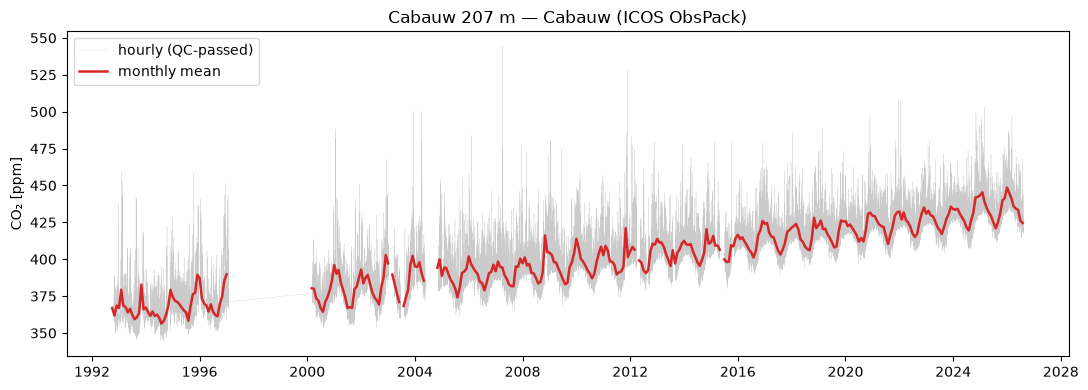

In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(s.index, s.values, lw=0.2, alpha=0.4, color="tab:gray",
        label="hourly (QC-passed)")
monthly = s.resample("MS").mean()
ax.plot(monthly.index, monthly.values, lw=1.8, color="tab:red",
        label="monthly mean")
ax.set_ylabel("CO₂ [ppm]")
ax.set_title(f"Cabauw 207 m — {ds.attrs.get('station_name', 'CBW')} (ICOS ObsPack)")
ax.legend(loc="upper left")
fig.tight_layout()

In [4]:
# The citation to put in your paper rides in the group attributes:
print(ds.attrs["co2_dobj_citation"])
print()
print("licence:", ds.attrs["license"], "| release DOI: 10.18160/JZ2X-GZGU")

Frumau, A., Hensen, A., Vermeulen, A. (2026). Atmospheric CO2 product from Cabauw (207.0 m), 1992-10-23–2026-03-31, European ObsPack, https://hdl.handle.net/11676/zB-wJRBhG_DpbHkY3Kuvjsa_

licence: CC-BY-4.0 | release DOI: 10.18160/JZ2X-GZGU


## Lazy by design: slice first, load less

Everything above read the full 30-year series. But `open_zarr` is **lazy** —
opening costs one metadata request, and `.sel()` on the lazy array is free;
bytes only move at `.load()` (or `.values`), and only for the chunks covering
your selection. For one summer instead of three decades:

In [5]:
import time

t0 = time.perf_counter()
fresh  = xr.open_zarr("https://zarr.icos-cp.eu/icos-obspack.zarr/CBW207",
                      consolidated=True)               # metadata only
summer = fresh["co2"].sel(time_co2=slice("2023-06-01", "2023-09-01")).load()
print(f"{summer.sizes['time_co2']:,} of {fresh.sizes['time_co2']:,} samples in "
      f"{time.perf_counter()-t0:.2f} s — only the chunks under the window moved")

2,232 of 296,266 samples in 0.13 s — only the chunks under the window moved


The same pattern is what makes the big stores usable at all: the SOCAT
gridded cube or a 44M-row obs table would be hopeless to download, but a lazy
`.sel()` box on them costs only the chunks it touches (notebooks 04–05).

## The citable route: the same series via `icoscp_core`

The Zarr store is the *analysis* route — merged across releases, longest
coverage. When your paper needs *the* released, frozen file behind a figure,
fetch it as a portal data object with
[`icoscp_core`](https://pypi.org/project/icoscp-core/). Discovery and citation
metadata are anonymous:

In [6]:
from icoscp_core.icos import meta

OBSPACK_CO2 = "http://meta.icos-cp.eu/resources/cpmeta/ObspackTimeSerieResult"
cbw  = next(s for s in meta.list_stations() if s.id == "CBW")
dobj = next(o for o in meta.list_data_objects(datatype=OBSPACK_CO2, station=cbw.uri)
            if "207" in o.filename)
print(dobj.filename, f"({dobj.size_bytes/1e6:.1f} MB)")
print()
print(meta.get_dobj_meta(dobj.uri).references.citationString)

co2_cbw_tower-insitu_445_207magl.nc (4.3 MB)

Frumau, A., Hensen, A., Vermeulen, A., Hilland, R., van den Bulk, P. (2026). Obspack CO2 time-series result from Cabauw (207.0 m), 1992-10-23–2026-08-05, European ObsPack, https://hdl.handle.net/11676/2QX5BX64k47kopRawJmsFCSF


Reading the object's data columns
(`data.get_columns_as_arrays(dobj)`, ~0.1 s) needs a free
[ICOS Carbon Portal account](https://cpauth.icos-cp.eu/) — notebook 01 walks
that route end-to-end. Rule of thumb: **analysis → Zarr, citation → portal
object.**

## Your data passport — on demand

Every chunk you just read was aggregated into a per-client session on the
server. Ask for your **data passport** when you're done: the request closes
the session and returns the passport immediately — an RO-Crate JSON-LD record
of exactly what you accessed (groups, arrays, byte counts, access date,
citation, licence, integrity hash). Reads after this simply start a new
session. (Idle sessions close on their own after ~5 minutes, and a closed
session's passport stays retrievable for an hour.)

In [7]:
import json, requests

r = requests.get(
    "https://zarr.icos-cp.eu/icos-obspack.zarr/session/passport").json()
passport = r["passport"]
rec = passport["@graph"][1]
print("accessed:", rec["accessedGroups"], "on", rec["dateAccessed"])
print("sha256:  ", rec["passportSha256"][:32], "…")
with open("cbw207_passport.json", "w") as f:
    json.dump(passport, f, indent=2)
print("saved → cbw207_passport.json  (keep it next to your results)")

accessed: ['CBW207', 'co2'] on 2026-08-17T17:11:09Z
sha256:   37ae29a0c5bc83de8c6188aa5a28629f …
saved → cbw207_passport.json  (keep it next to your results)
